In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded")

All libraries loaded


In [2]:
final_df = pd.read_parquet("../data_storage/streamlit_app_data/final_dataset_with_attribution.parquet")

In [3]:
final_df.head(2)

,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,people_by_row,publication_name,...,vipr_score,vipr_weight,people_by_row_clean,headline_token_count,body_token_count,token_count,emotion_body,seq_index,circulation_size_bin,sentiment_score_bin
0,juliann ventura hill posted dec cst updated de...,18918986050,juliann_ventura,web,47759,opoint,warren rfk pick say goodbye smile say hello polio,2,"Elizabeth Warren, Juliann Ventura, Robert F Ke...",cw33,...,9872,617,"Elizabeth Warren, Juliann Ventura, Robert F Ke...",9,329,338,fear,1,4,5
1,geneva switzerland may ani health leaders coun...,18284984014,unknown,web,950,opoint,asia pacific countries sound alarm commit tack...,5,"Timor Leste, Vanuatu, Saia Piukala, Shiozaki A...",the_tennis_times,...,19500,1300,"Timor Leste, Vanuatu, Saia Piukala, Shiozaki A...",9,462,471,fear,2,1,5


In [4]:
final_df.columns

Index(['article_body', 'article_id', 'author_name', 'channel_name',
       'circulation_size', 'feed_name', 'headline', 'hit_strength',
       'people_by_row', 'publication_name', 'published_datetime',
       'publisher_name', 'sentiment_band', 'sentiment_score',
       'source_feed_name', 'source_type', 'tag_name', 'vipr_score',
       'vipr_weight', 'people_by_row_clean', 'headline_token_count',
       'body_token_count', 'token_count', 'emotion_body', 'seq_index',
       'circulation_size_bin', 'sentiment_score_bin'],
      dtype='object')

In [11]:
tagname_df = pd.read_parquet("/Users/annaglass/capstone/capstone/data_storage/final_data/tagname_pca_ready.parquet")

In [12]:
tagname_df.head(2)

,tag_name,n_rows,n_conv,conv_rate,avg_vipr_weight,avg_circulation_size,avg_sentiment_score,avg_headline_token_count,avg_body_token_count,avg_token_count,avg_abs_sentiment
0,health_campaign,1958,1742,0.889683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,last_smoke_campaign,1,1,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
person_df = pd.read_parquet("../data_storage/final_data/persons_detected.parquet")

In [15]:
person_df.head(2)

,person,count
0,Donald Trump,5807
1,Robert F Kennedy,3817


In [18]:
person_row_df = pd.read_parquet("../data_storage/final_data/persons_by_row.parquet")

In [19]:
person_row_df.head(2)

,row_index,tag_name,persons,has_person
0,0,public_health,<NA>,0
1,1,public_health,"Elizabeth Warren, Juliann Ventura, Robert F Ke...",1


In [20]:
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

In [21]:
K_MIN, K_MAX = 2, 10
RANDOM_STATE = 42
SAVE_OUTPUTS = False

In [22]:
# ==== 2) STABLE KEY & FEATURE SELECTION ====
df = final_df.copy().reset_index().rename(columns={'index':'row_index'})

# Candidate numeric features (edit if you want extras)
candidate_numeric = [
    'vipr_score', 'vipr_weight', 'hit_strength', 'sentiment_score',
    'circulation_size', 'headline_token_count', 'body_token_count', 'token_count'
]
binary_flags = [c for c in ['has_person','is_conversion'] if c in df.columns]

feature_cols = [c for c in candidate_numeric if c in df.columns] + binary_flags
for c in binary_flags:
    df[c] = df[c].astype(int)

print("Using feature columns:", feature_cols)
X = df[feature_cols].to_numpy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Using feature columns: ['vipr_score', 'vipr_weight', 'hit_strength', 'sentiment_score', 'circulation_size', 'headline_token_count', 'body_token_count', 'token_count']


In [23]:
# ==== 3) PCA (retain ~90% variance) ====
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cum_var, 0.90) + 1)
print(f"Components needed for ~90% variance: {n_components_90}")

pca = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pc_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)
df_pca['row_index'] = df['row_index']
for col in ['author_name','tag_name']:
    if col in df.columns: df_pca[col] = df[col]

print("df_pca shape:", df_pca.shape)

Components needed for ~90% variance: 6
df_pca shape: (45386, 9)


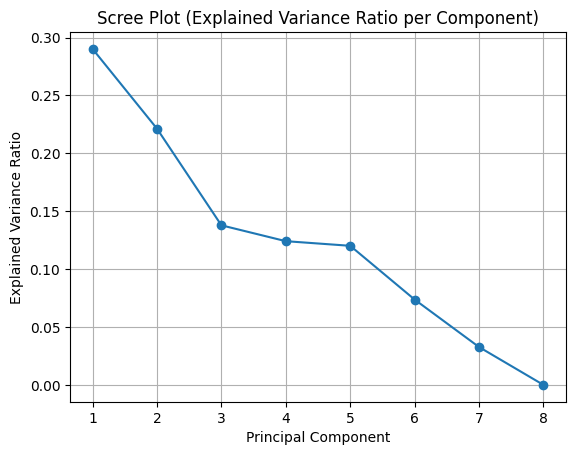

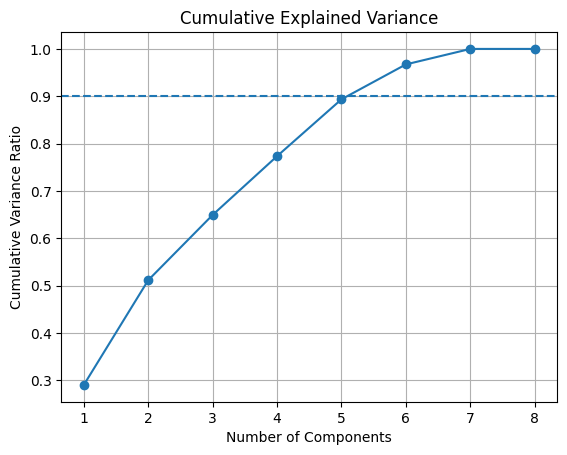

In [24]:
# ==== 4) Diagnostics: Scree & Cumulative Variance ====
plt.figure()
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_, marker='o')
plt.title('Scree Plot (Explained Variance Ratio per Component)')
plt.xlabel('Principal Component'); plt.ylabel('Explained Variance Ratio')
plt.grid(True); plt.show()

plt.figure()
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.90, linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Variance Ratio')
plt.grid(True); plt.show()

,k,inertia,silhouette
0,2,288558.429804,0.639803
1,3,245621.077141,0.248167
2,4,210030.367616,0.247052
3,5,182694.462672,0.248632
4,6,161011.298914,0.261060
5,7,143986.741272,0.219057
6,8,129471.437008,0.221780
7,9,119508.275767,0.228978
8,10,111368.699284,0.207584


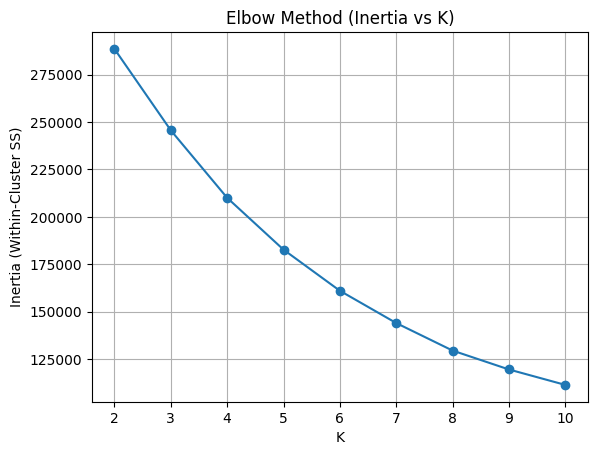

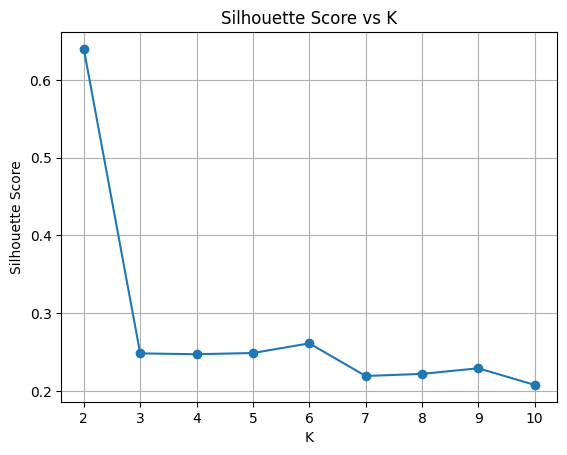

Optimal K (by silhouette max): 2


In [25]:
# ==== 5) CHOOSE K via Elbow & Silhouette ====
k_values = list(range(K_MIN, K_MAX + 1))
inertias, sil_scores = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

elbow_sil_df = pd.DataFrame({'k': k_values, 'inertia': inertias, 'silhouette': sil_scores})
display(elbow_sil_df)

plt.figure()
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method (Inertia vs K)')
plt.xlabel('K'); plt.ylabel('Inertia (Within-Cluster SS)')
plt.grid(True); plt.show()

plt.figure()
plt.plot(k_values, sil_scores, marker='o')
plt.title('Silhouette Score vs K')
plt.xlabel('K'); plt.ylabel('Silhouette Score')
plt.grid(True); plt.show()

optimal_k = int(elbow_sil_df.loc[elbow_sil_df['silhouette'].idxmax(), 'k'])
print("Optimal K (by silhouette max):", optimal_k)

In [26]:
# ==== 6) FINAL KMeans at optimal_k ====
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
df_pca['cluster'] = kmeans_final.fit_predict(X_pca)

centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=pc_cols)
centroids.insert(0, 'cluster', range(optimal_k))

print("Cluster sizes:")
print(df_pca['cluster'].value_counts().sort_index())
centroids

Cluster sizes:
cluster
0     1615
1    43771
Name: count, dtype: int64


,cluster,PC1,PC2,PC3,PC4,PC5,PC6
0,0,6.004305,-0.999617,-0.473718,-0.205322,-0.041261,-0.269950
1,1,-0.221681,0.036906,0.017490,0.007581,0.001523,0.009967


In [27]:
# ==== 7) INTERPRET CLUSTERS WITH ORIGINAL METRICS ====
metrics_cols = [c for c in ['vipr_score','vipr_weight','sentiment_score','circulation_size'] if c in df.columns]
interp_df = df[['row_index'] + metrics_cols].merge(df_pca[['row_index','cluster']], on='row_index', how='left')
cluster_summary = interp_df.groupby('cluster')[metrics_cols].mean().reset_index()
display(cluster_summary)

,cluster,vipr_score,vipr_weight,sentiment_score,circulation_size
0,0,-4624.575851,818.780186,-4.570898,4802686.128173
1,1,-6082.364214,674.669119,-7.552443,2238016.811176


In [35]:
#### Cluster 0 : dominant cluster, representing the vast majority of articles or authors 
#### Baseline cluster:  average visibility, typical sentiment, and moderate engagement

#### Cluster 1 : high-impact cluster, showing substantially different PCA scores
#### High-Impact cluster: likely top influencers or amplification outliers

In [28]:
# ==== 8) BUILD INFLUENCER TABLE from person_row_df ====
def _split_persons(s):
    if pd.isna(s): return []
    return [p.strip() for p in str(s).split(',') if str(p).strip()]

influencer_table = None
if 'person_row_df' in globals() and isinstance(person_row_df, pd.DataFrame) \
   and {'row_index','persons'}.issubset(person_row_df.columns):
    merged = (
        person_row_df[['row_index','persons']]
        .merge(df_pca[['row_index','cluster']], on='row_index', how='left')
        .merge(df[['row_index'] + metrics_cols], on='row_index', how='left')
    )
    merged['person_list'] = merged['persons'].apply(_split_persons)
    exploded = merged.explode('person_list').dropna(subset=['person_list'])

    agg_dict = {m: 'mean' for m in metrics_cols}
    agg_dict.update({'row_index': 'count'})  # mention_count
    influencer_table = (
        exploded.groupby(['person_list','cluster'])
                .agg(agg_dict)
                .rename(columns={'row_index':'mention_count'})
                .reset_index()
    )

    # Simple, interpretable cluster labels
    lab = cluster_summary.copy()
    def _label_row(r):
        vis  = r.get('vipr_score', np.nan)
        tone = r.get('sentiment_score', np.nan)
        if pd.notna(vis) and pd.notna(tone):
            vis_med = np.nanmedian(cluster_summary.get('vipr_score', pd.Series([vis])))
            if vis >= vis_med and tone >= 0:  return "High Visibility / Positive Tone"
            if vis >= vis_med and tone < 0:   return "High Visibility / Negative Tone"
            if vis < vis_med and tone >= 0:   return "Lower Visibility / Positive Tone"
            return "Lower Visibility / Negative Tone"
        return "Unlabeled"
    lab['cluster_label'] = lab.apply(_label_row, axis=1)

    influencer_table = influencer_table.merge(lab[['cluster','cluster_label']], on='cluster', how='left')

    # Rank by mention_count, then vipr_score if present
    sort_cols, sort_asc = ['mention_count'], [False]
    if 'vipr_score' in influencer_table.columns:
        sort_cols.append('vipr_score'); sort_asc.append(False)
    influencer_table = influencer_table.sort_values(sort_cols, ascending=sort_asc).reset_index(drop=True)

    display(influencer_table.head(25))
else:
    print("person_row_df missing or lacks required columns {'row_index','persons'}; influencer table not built.")

,person_list,cluster,vipr_score,vipr_weight,sentiment_score,circulation_size,mention_count,cluster_label
0,Donald Trump,1.0,-5806.987976,674.935541,-7.419279,1664502.744333,5073,Lower Visibility / Negative Tone
1,Robert F Kennedy,1.0,-5692.347013,674.621304,-7.132167,2142094.277308,3314,Lower Visibility / Negative Tone
2,Joe Biden,1.0,-5554.44354,653.961998,-7.336048,1970587.057003,1842,Lower Visibility / Negative Tone
3,Tedros Ghebreyesus,1.0,-6702.509058,703.144022,-8.445652,1806224.230978,1104,Lower Visibility / Negative Tone
4,Kamala Harris,1.0,-5613.914761,668.567568,-7.727651,1868700.29106,481,Lower Visibility / Negative Tone
5,Anthony Fauci,1.0,-4283.206977,669.606977,-8.613953,543619.92093,430,Lower Visibility / Negative Tone
6,Elon Musk,1.0,-5405.408219,631.375342,-7.567123,2165831.169863,365,Lower Visibility / Negative Tone
7,George Bush,1.0,-2460.922297,694.783784,-3.297297,1268660.665541,296,Lower Visibility / Negative Tone
8,Christian Mike,1.0,-5759.460751,670.221843,-8.426621,314575.020478,293,Lower Visibility / Negative Tone
9,Barack Obama,1.0,-4906.085616,667.736301,-6.380137,1158728.979452,292,Lower Visibility / Negative Tone


In [29]:
influencer_table.query("cluster == 1").head(25)

,person_list,cluster,vipr_score,vipr_weight,sentiment_score,circulation_size,mention_count,cluster_label
0,Donald Trump,1.0,-5806.987976,674.935541,-7.419279,1664502.744333,5073,Lower Visibility / Negative Tone
1,Robert F Kennedy,1.0,-5692.347013,674.621304,-7.132167,2142094.277308,3314,Lower Visibility / Negative Tone
2,Joe Biden,1.0,-5554.44354,653.961998,-7.336048,1970587.057003,1842,Lower Visibility / Negative Tone
3,Tedros Ghebreyesus,1.0,-6702.509058,703.144022,-8.445652,1806224.230978,1104,Lower Visibility / Negative Tone
4,Kamala Harris,1.0,-5613.914761,668.567568,-7.727651,1868700.29106,481,Lower Visibility / Negative Tone
5,Anthony Fauci,1.0,-4283.206977,669.606977,-8.613953,543619.92093,430,Lower Visibility / Negative Tone
6,Elon Musk,1.0,-5405.408219,631.375342,-7.567123,2165831.169863,365,Lower Visibility / Negative Tone
7,George Bush,1.0,-2460.922297,694.783784,-3.297297,1268660.665541,296,Lower Visibility / Negative Tone
8,Christian Mike,1.0,-5759.460751,670.221843,-8.426621,314575.020478,293,Lower Visibility / Negative Tone
9,Barack Obama,1.0,-4906.085616,667.736301,-6.380137,1158728.979452,292,Lower Visibility / Negative Tone


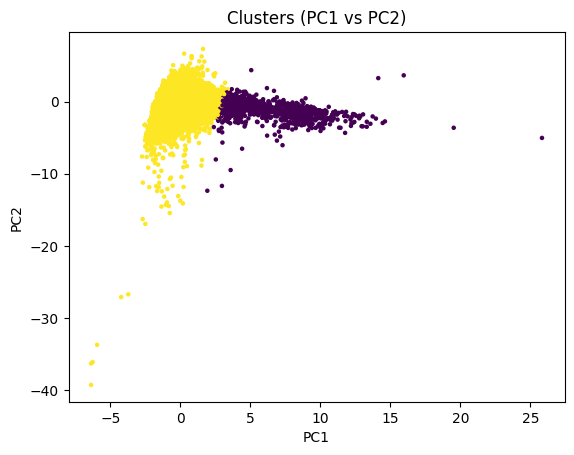

In [30]:
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['cluster'], s=5, cmap='viridis')
plt.title("Clusters (PC1 vs PC2)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()